In [1]:
import jax
import jax.numpy as jnp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple

### MOCK Demo Notebook by Michael Wells 5/28/2026

We perform the entire MOCK pipeline in this notebook.  We generate simulated data from the 2D FHN dataset and fit the MOCK model to it.  We use a Gaussian kernel with bandwidth given by the median heuristic.  We tune the regularization parameter using a held-out validation set.  Next, we fit the tuned MOCK model on the combined training + validation sets.  Lastly, we visualize the model on the test set and compute an error evaluation metric on predicted vs true test trajectories.

This MOCK pipeline was implemented using the JAX library.  It supports computation with a GPU.

### Numerical integration

Below is an implementation of a 4th-order Runge-Kutta numerical integration method.  This code can integrate multiple trajectories simultaneously.

Numerical integration is the process by which a trajectory satisfying a differential equation is obtained given an initial condition.  We start from an initial condition (here stored in the variable `x0`) and proceed to move the state forward in time by following the vector field.  We store the states corresponding to timestamps stored in the `t` variable, which will be a list of jax arrays storing the timestamps for each trajectory to be integrated.

We take advantage of the JAX feature to compile code blocks into a low-level language and store the resulting machine code in RAM.  The `jax.jit` function will compile Python functions.  The function `jax.lax.scan` is specially-designed to compile for-loops in which a state is carried from one iteration to the next.  Here, we have compiled the entire for-loop used for integrating.  The function `main_loop_fast` executes a single integration step and stores the result, as well as recording the result in a history of states.  The collection of states obtained through integration is stored in the `history` variable.

In [2]:
def main_loop_fast(f: Callable[[jnp.ndarray], jnp.ndarray], xi: jnp.ndarray, step_size: float) -> Tuple[jnp.ndarray, jnp.ndarray]:
    '''
    Perform a single step of the RK4 method.
    Args:
        f: function that takes in a state and returns the derivative of the state
        xi: current state, shape (num_traj, d)
        step_size: step size for RK4 solver
    Returns:
        new_state: updated state after one RK4 step, shape (num_traj, d)
        new_state: same as new_state (for compatibility with jax.lax.scan)
    '''
    k1 = f(xi)
    k2 = f(xi + 0.5 * step_size * k1)
    k3 = f(xi + 0.5 * step_size * k2)
    k4 = f(xi + step_size * k3)
    new_state = xi + step_size / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return new_state, new_state


def rk4_solver_fast(f: Callable[[jnp.ndarray], jnp.ndarray], x0: jnp.ndarray, t: List[jnp.ndarray], step_size: float) -> List[jnp.ndarray]:
    '''
    Fast version of RK4 solver that uses jax.lax.scan to speed up the for loop. This is much faster than the original rk4_solver, especially for long trajectories.
    Args:
        f: function that takes in a state and returns the derivative of the state
        x0: initial state, shape (num_traj, d)
        t: list of time points for each trajectory, shape (num_traj, num_time_points)
        step_size: step size for RK4 solver
    Returns:
        traj: list of trajectories, each trajectory is a jax array of shape (num_time_points, d)
    '''
    num_traj = x0.shape[0]
    d = x0.shape[1]
    if num_traj != len(t):
        raise ValueError('Number of trajectories in x0 and t must be the same')
    left = [t[i][0] for i in range(num_traj)]
    right = [t[i][-1] for i in range(num_traj)]
    num_steps = int(max([jnp.ceil((right[i] - left[i]) / step_size) + 1 for i in range(num_traj)]))  # type: ignore
    tstar = [jnp.linspace(left[i], left[i] + (num_steps-1)*step_size, num_steps) for i in range(num_traj)]
    tindex = [jnp.argmin(jnp.abs(tstar[i][:, None] - t[i]), axis=0) for i in range(num_traj)]
    x = x0[:, None, :] # shape (num_traj, 1, d)
    main_loop_jit = jax.jit(main_loop_fast, static_argnums=(0,2))
    x_final, history = jax.lax.scan(lambda carry, _: main_loop_jit(f, carry, step_size), x0, jnp.arange(num_steps-1))
    history = jnp.transpose(history, (1,0,2))
    x = jnp.concatenate([x0[:, None, :], history, x_final[:, None, :]], axis=1)
    traj = [x[i, tindex[i]] for i in range(num_traj)] # Only keep the time points that are in t
    return traj

### FHN model

As a demo for the MOCK algorithm, we select the 2D FHN model to use as the true vector field.  We simulate data: 100 trajectories with 101 equispaced time points each in the interval [0, 10].

In [3]:
def FHN_vector_field(state: jnp.ndarray) -> jnp.ndarray:
    '''
    Compute the vector field of the FitzHugh-Nagumo model.
    Args:
        state: current state, shape (num_traj, 2)
    Returns:
        derivative: derivative of the state, shape (num_traj, 2)
    '''
    v = state[:, 0]
    w = state[:, 1]
    dvdt = v - v**3 / 3 - w + 0.1
    dwdt = 0.08 * (v + 0.7 - 0.8 * w)
    return jnp.stack([dvdt, dwdt], axis=-1)

In [ ]:
rng = jax.random.PRNGKey(0)  # Use a fixed random seed for reproducibility
num_traj = 100
num_time_points = 101
t = [jnp.linspace(0, 10, num_time_points) for _ in range(num_traj)]
x0 = jax.random.uniform(rng, (num_traj, 2), minval=-2.0, maxval=2.0)
traj = rk4_solver_fast(FHN_vector_field, x0, t, step_size=0.01)

### Plotting

We use `matplotlib.pyplot` for plotting.  Here the FHN trajectories are displayed in blue with their initial conditions in red.

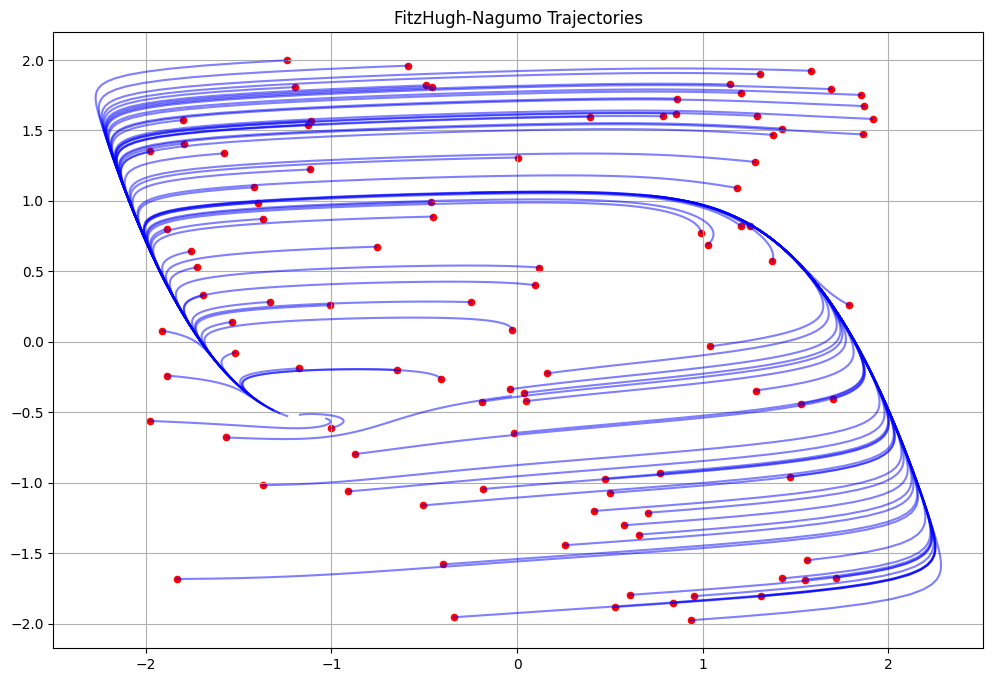

In [5]:
plt.figure(figsize=(12, 8))
for i in range(num_traj):
    plt.plot(traj[i][:, 0], traj[i][:, 1], color='blue', alpha=0.5)
    plt.scatter(traj[i][0, 0], traj[i][0, 1], color='red', s=20)  # Initial point
plt.title('FitzHugh-Nagumo Trajectories')
plt.grid()
plt.show()

Split the data into 70\% train, 10\% validate, and 20\% test.

In [6]:
num_train_traj = int(num_traj * 0.7)
num_val_traj = int(num_traj * 0.1)
num_test_traj = num_traj - num_train_traj - num_val_traj
rng, _ = jax.random.split(rng)
train_traj_idx = jax.random.choice(rng, num_traj, (num_train_traj,), replace=False)
remaining_idx = jnp.setdiff1d(jnp.arange(num_traj), train_traj_idx)
rng, _ = jax.random.split(rng)
val_traj_idx = jax.random.choice(rng, remaining_idx, (num_val_traj,), replace=False)
test_traj_idx = jnp.setdiff1d(remaining_idx, val_traj_idx)
traj_train = [traj[i] for i in train_traj_idx]
traj_val = [traj[i] for i in val_traj_idx]
traj_test = [traj[i] for i in test_traj_idx]
t_train = [t[i] for i in train_traj_idx]
t_val = [t[i] for i in val_traj_idx]
t_test = [t[i] for i in test_traj_idx]

### Gaussian kernel

Kernel function given by $K(x,y) = \exp(\frac{-\|x-y\|^2}{2\sigma^2})$. 

Kernel functions are generalized similarities that correspond to certain Hilbert spaces of functions.  With the Gaussian kernel, the corresponding Hilbert space consists of functions which are weighted sums of Gaussian pdf's.  Through the representer theorem, kernels enable us to optimize over infinite-dimensional spaces of functions.

The parameter $\sigma$ is known as the bandwidth.  The bandwidth controls the shape of the kernel.  A low bandwidth means only points that are close together will have significant similarity in terms of the kernel.  Conversely, a high bandwidth means that distant points will have high similarity.

The code is vectorized to handle multiple inputs.  It takes in collections of datapoints in $[x]$ and $[y]$ and returns the Gram matrix of pairwise kernel evaluations $[K(x,y)]$.


In [7]:
def gaussian_kernel(x: jnp.ndarray, y: jnp.ndarray, bw: float = 1.0) -> jnp.ndarray:
    '''Compute the Gaussian kernel between two sets of vectors.
    Args:
        x: jax array of shape (n, d)
        y: jax array of shape (m, d)
        bw: bandwidth of the kernel
    Returns:
        kernel: jax array of shape (n, m)
    '''
    norm2x = jnp.linalg.norm(x, axis=-1) ** 2
    norm2y = jnp.linalg.norm(y, axis=-1) ** 2
    cross = x @ jnp.swapaxes(y, -1, -2)
    return jnp.exp(-0.5 * (norm2x[:, None] + norm2y[None, :] - 2 * cross) / bw**2)

### Median heuristic for Gaussian kernel bandwidth

It has been established that setting the bandwidth of the Gaussian kernel to be
\begin{equation}
\sigma = \text{median}\left\{\|y_i - y_j\|\right\}_{y_i \neq y_j \in \mathcal{D}}
\end{equation}
is effective for most applications.  Thus, we do not need to tune this parameter in a validation loop.

In [8]:
traj_concat = jnp.concatenate(traj, axis=0)  # shape (num_traj * num_time_points, 2)
diffs = jnp.linalg.norm(traj_concat[:, None, :] - traj_concat[None, :, :], axis=-1)
diffs = diffs[jnp.triu_indices(diffs.shape[0], k=1)]  # Get upper triangular part of the distance matrix
bw = jnp.median(diffs)
kernel = lambda x, y: gaussian_kernel(x, y, bw=bw)

## MOCK algorithm

The MOCK algorithm finds the minimizer of the cost function
\begin{equation}
J(f) = \frac{1}{n}\sum_{i=1}^n \left\|\int_{t_i}^{t_{i+1}}f(x(t))dt - (y_{i+1} - y_i)\right\|^2 + \lambda \|f\|^2_H
\end{equation}
over a Hilbert space $H$ corresponding to a kernel $K$ (in this case, the Gaussian kernel).

The optimal $f^*$ will be a linear combination of
\begin{equation}
f^* = \sum_{i=1}^n \alpha_i L_i^*
\end{equation}
where $L_i^* \in H$ are Riesz dual functions (called "occupation kernels") given by
\begin{equation}
L_i^* = \int_{t_i}^{t_{i+1}}K(\cdot, x(t)) dt
\end{equation}
The coefficients $\alpha_i$ are found by solving the linear system
\begin{equation}
(L^* + n\lambda I)\alpha = \Delta y_i
\end{equation}
where $L^*$ is the $(n, n)$ matrix of inner products:
\begin{equation}
[L^*]_{ij} = \langle L_i^*, L_j^* \rangle_H = \int_{t_i}^{t_{i+1}}\int_{t_j}^{t_{j+1}}K(x(s), x(t)) ds dt
\end{equation}

### MOCK implementation

In this MOCK implementation, we avoid all use of for-loops with vectorized code.  We use `jax.jit` to speed up computation (note: functions should be jit-compiled only if they will be called multiple times with identically-shaped input).  The code also will check the condition number of the matrix $L^* + n\lambda I$ and add more regularization if it is too large.  This forces the condition number to be less than or equal to a pre-defined max threshold.

The function `get_MOCK_vector_field` will fit the MOCK model to the data and return a callable Python function that gives the predicted vector field.

It takes as arguments:

`t_list`: list of timepoints in dataset stored as jax arrays.  Each array has shape (num_time_pts,)

`traj_list`: list of trajectories in dataset stored as jax arrays.  Each array has shape (num_time_pts, input_dim)

`kernel`: A callable function that gives the kernel.

`lam`:  The regularization parameter.  Must be a positive float.

`max_cond_num`:  Maximum allowed condition number for the matrix $L^* + n\lambda I$.  Must be a positive float.

`check_cond_num`:  A boolean flag indicating whether the condition number will be checked or not.

In [9]:
def compute_traj_idx_concat(t_list):
    '''
    Compute concatenated trajectory indices excluding the last index of each trajectory.
    '''
    t_lens = [len(t) for t in t_list]
    t_lens = jnp.array(t_lens)
    t_lens_cumsum = jnp.cumsum(t_lens) - 1
    idx_grid = jnp.arange(t_lens_cumsum[-1])
    traj_idx_concat = jnp.setdiff1d(idx_grid, t_lens_cumsum)
    return traj_idx_concat


def compute_L_star(t_concat, traj_concat, traj_idx_concat, delta_y_concat, kernel):
    '''
    Compute the L* matrix used in the MOCK algorithm.
    '''
    K_mat = kernel(traj_concat, traj_concat)
    K_mat = K_mat[1:] + K_mat[:-1]
    K_mat = K_mat[:, 1:] + K_mat[:, :-1]
    K_mat = K_mat[traj_idx_concat[:, None], traj_idx_concat[None, :]]
    delta_t = t_concat[1:] - t_concat[:-1]
    delta_t = delta_t[traj_idx_concat]
    K_mat = K_mat * delta_t[None, :]/2.0 * delta_t[:, None]/2.0
    return K_mat



def compute_mats(L_star, delta_y_concat, lam):
    '''
    Compute the alpha coefficients for the MOCK algorithm.
    '''
    n = L_star.shape[0]
    A = L_star + n*lam * jnp.eye(n)
    b = delta_y_concat
    return A, b

def find_alpha(A, b):    
    '''
    Solve the linear system A * alpha = b to find the alpha coefficients.
    '''
    alpha = jnp.linalg.solve(A, b)
    return alpha

def check_condition_number(A, max_cond_num):
    '''
    Check the condition number of matrix A and apply regularization if it exceeds max_cond_num.
    '''
    cond_num = jnp.linalg.cond(A)
    if cond_num > max_cond_num:
        print(f"Warning: Condition number of A is {cond_num}, which may lead to numerical instability.")
        print(f"Applying regularization to improve conditioning.")
        eigvals, _ = jnp.linalg.eigh(A)
        max_eigval = jnp.max(eigvals)
        min_eigval = jnp.min(eigvals)
        kappa = (max_eigval - min_eigval*max_cond_num)/(max_cond_num - 1)  
        A += kappa * jnp.eye(A.shape[0])  # Will force the condition number to be at most max_cond_num
    return A

compute_mats_jit = jax.jit(compute_mats, static_argnums=(2,))
find_alpha_jit = jax.jit(find_alpha)
compute_L_star_jit = jax.jit(compute_L_star, static_argnums=(4,))

def compute_MOCK_parameters(t_list, traj_list, kernel, lam, max_cond_num = 1e10, check_cond_num = True):
    '''
    Compute MOCK parameters including alpha coefficients and concatenated trajectories.
    '''
    t_concat = jnp.concatenate(t_list, axis=0)
    traj_concat = jnp.concatenate(traj_list, axis=0)
    delta_y_concat = traj_concat[1:] - traj_concat[:-1]
    traj_idx_concat = compute_traj_idx_concat(t_list)
    delta_y_concat = delta_y_concat[traj_idx_concat]
    L_star = compute_L_star_jit(t_concat, traj_concat, traj_idx_concat, delta_y_concat, kernel)
    A, b = compute_mats_jit(L_star, delta_y_concat, lam)
    if check_cond_num:
        A = check_condition_number(A, max_cond_num)
    alpha = find_alpha_jit(A, b)
    return alpha, traj_concat, t_concat, traj_idx_concat


def get_MOCK_vector_field(t_list, traj_list, kernel, lam, max_cond_num = 1e10, check_cond_num = True):
    '''
    Compute the MOCK vector field function based on input trajectories and kernel.
    '''
    alpha, traj_concat, t_concat, traj_idx_concat = compute_MOCK_parameters(t_list, traj_list, kernel, lam)
    def f_MOCK(x):  # Returns the vector field at points x
        K_eval_train = kernel(x, traj_concat)
        K_eval_train = K_eval_train[:, 1:] + K_eval_train[:,:-1]
        K_eval_train = K_eval_train[:, traj_idx_concat]
        delta_t = t_concat[1:] - t_concat[:-1]
        delta_t = delta_t[traj_idx_concat]
        K_eval_train = K_eval_train * delta_t[None, :]/2.0
        f_x = K_eval_train @ alpha
        return f_x
    return f_MOCK

### Error evaluation function:

Computes the error between predicted trajectory $\hat{x}$ and true trajectory $x$ by approximating the $L^2$-squared error:
\begin{equation}
Err = \sum_{i=1}^{n-1}\Delta t_i \cdot \|\hat{x}(t_{i+1}) - x(t_{i+1})\|^2
\end{equation}
We take the mean over all trajectories in the dataset.  Vectorized to evaluate on multiple trajectories at once.

In [10]:
def compute_error(traj_true_concat: jnp.ndarray, traj_pred_concat: jnp.ndarray, delta_t: float) -> float:
    # Compute the mean squared error between the true trajectories and the predicted trajectories
    mse = num_time_points* jnp.mean(delta_t*(traj_true_concat - traj_pred_concat) ** 2)
    return mse

In [11]:
compute_error_jit = jax.jit(compute_error)

In [12]:
lam_list = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]  # List of lambda values to try for regularization

In [13]:
traj_val_concat = jnp.concatenate([traj_val[i][1:] for i in range(len(traj_val))], axis=0)
delta_t_val = [t_val[i][1:] - t_val[i][:-1] for i in range(len(t_val))]
delta_t_val_concat = jnp.concatenate(delta_t_val, axis=0)[:, None]
x0_val = [traj_val[i][0][None, :] for i in range(len(traj_val))]
x0_val = jnp.concatenate(x0_val, axis=0)

### Validating $\lambda$

We find the optimal regularization parameter $\lambda$ using a held-out validation set.  We fit the model multiple times to the training set using different values for $\lambda$ and select the one that produces the lowest error on the validation set.

For each $\lambda$ in a pre-defined list, we execute the following steps:

1) Fit MOCK to training set with a candidate regularization parameter $\lambda$ from the list.

2) Integrate trajectories in the validation set with predicted MOCK vector field.

3) Compute the error between predicted and true trajectories in validation set.

4) If the error is better than the current best error recorded, store the $\lambda$ value as the best regularization parameter.

We store the final best regularization parameter in the variable `best_lam`

In [14]:
errs = np.zeros(len(lam_list))
best_lam = None
best_err = float('inf')
for i, lam in enumerate(lam_list):
    f_MOCK = get_MOCK_vector_field(t_train, traj_train, kernel, lam)
    traj_pred = rk4_solver_fast(f_MOCK, x0_val, t_val, step_size=0.01)
    traj_pred_concat = jnp.concatenate([traj_pred[i][1:] for i in range(len(traj_pred))], axis=0)
    errs[i] = compute_error_jit(traj_val_concat, traj_pred_concat, delta_t_val_concat)
    print(f"Lambda: {lam}, Err: {errs[i]}")
    if errs[i] < best_err:
        best_err = errs[i]
        best_lam = lam
print(f"Best lambda: {best_lam}, Best Err: {best_err}")

Applying regularization to improve conditioning.
Lambda: 1e-10, Err: 0.229991614818573
Lambda: 1e-09, Err: 0.03624308109283447
Lambda: 1e-08, Err: 0.00275745359249413
Lambda: 1e-07, Err: 0.0018859556876122952
Lambda: 1e-06, Err: 0.04542054980993271
Lambda: 1e-05, Err: 0.49311837553977966
Lambda: 0.0001, Err: 2.662588357925415
Lambda: 0.001, Err: 8.803717613220215
Lambda: 0.01, Err: 19.008113861083984
Lambda: 0.1, Err: 21.253684997558594
Best lambda: 1e-07, Best Err: 0.0018859556876122952


### Fitting tuned model on whole training set

Next, we fit the MOCK model to the combined training and validation sets using the tuned $\lambda$.

In [15]:
train_train_val = traj_train + traj_val
t_train_val = t_train + t_val
f_MOCK_final = get_MOCK_vector_field(t_train_val, train_train_val, kernel, best_lam)

### Integrating predicted trajectories on the test set

We integrate predicted trajectories using the initial conditions from the test set and the final MOCK vector field.

In [16]:
x0_test = [traj_test[i][0][None, :] for i in range(len(traj_test))]
x0_test = jnp.concatenate(x0_test, axis=0)
traj_pred_test = rk4_solver_fast(f_MOCK_final, x0_test, t_test, step_size=0.01)

### Visualizing the model

We plot the predicted test trajectories along with the true trajectories.  The two sets of trajectories ideally will sit on top of each other.

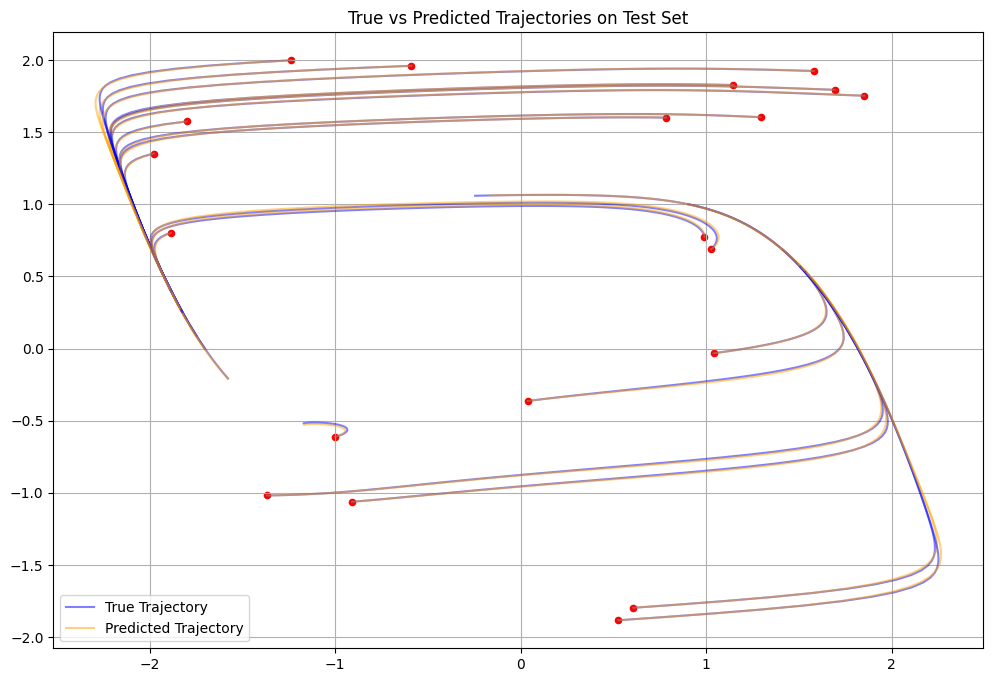

In [17]:
plt.figure(figsize=(12, 8))
for i in range(num_test_traj):
    plt.plot(traj_test[i][:, 0], traj_test[i][:, 1], color='blue', alpha=0.5, label='True Trajectory' if i == 0 else "")
    plt.plot(traj_pred_test[i][:, 0], traj_pred_test[i][:, 1], color='orange', alpha=0.5, label='Predicted Trajectory' if i == 0 else "")
    plt.scatter(traj_test[i][0, 0], traj_test[i][0, 1], color='red', s=20)  # Initial point
plt.title('True vs Predicted Trajectories on Test Set')
plt.legend()
plt.grid()
plt.show()

### Final model evaluation

Finally, we evaluate the model using the $L^2$-squared error metric, taking the mean value over all trajectories in the dataset.

\begin{equation}
Err_j = \sum_{i=1}^{n-1} \Delta t_i \cdot \|\hat{x}(t_{i+1}) - x(t_{i+1})\|^2,\;\; Err = \frac{1}{n}\sum_{j=1}^n Err_j
\end{equation}

In [18]:
test_pred_concat = jnp.concatenate([traj_pred_test[i][1:] for i in range(len(traj_pred_test))], axis=0)
delta_t_test = [t_test[i][1:] - t_test[i][:-1] for i in range(len(t_test))]
delta_t_test_concat = jnp.concatenate(delta_t_test, axis=0)[:, None]
test_true_concat = jnp.concatenate([traj_test[i][1:] for i in range(len(traj_test))], axis=0)
test_err = compute_error_jit(test_true_concat, test_pred_concat, delta_t_test_concat)
print(f"Test Err: {test_err}")

Test Err: 0.005219726823270321
